# Spin-Weighted Spherical Harmonic Transforms Demo

This notebook demonstrates both forward and inverse spin-weighted spherical harmonic transforms using S2FFT, comparing against healpy's reference implementation.

**Forward transform (map2alm_spin):** Converts Q/U Stokes parameter maps to E/B mode spherical harmonic coefficients

**Inverse transform (alm2map_spin):** Converts E/B mode coefficients back to Q/U maps

Both implementations are self-contained and independent of the jax-healpy library.

In [ ]:
import jax  # noqa: E402

jax.config.update('jax_enable_x64', True)

import healpy as hp  # noqa: E402
import jax.numpy as jnp  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
from jax import random  # noqa: E402
from s2fft.sampling.reindex import flm_2d_to_hp_fast, flm_hp_to_2d_fast  # noqa: E402
from s2fft.transforms import spherical as s2fft_spherical  # noqa: E402

## Function Definitions

Define the forward and inverse spin-weighted transforms using S2FFT.

In [2]:
def map2alm_spin_s2fft(q_map, u_map, *, spin, nside, lmax, method='jax'):
    """
    Forward spin-weighted transform: Q/U maps -> E/B mode coefficients.

    Approximates healpy.map2alm_spin using S2FFT.

    Parameters
    ----------
    q_map, u_map : array_like
        Q and U Stokes parameter maps
    spin : int
        Spin weight (typically 2 for CMB polarization)
    nside : int
        HEALPix resolution parameter
    lmax : int
        Maximum multipole moment
    method : str
        S2FFT computation method (default: "jax")

    Returns
    -------
    alm_plus, alm_minus : arrays
        For spin=2: alm_plus ~ E_lm, alm_minus ~ B_lm (healpy 1D format)
    """
    if spin == 0:
        raise ValueError('Use hp.map2alm for scalar transforms.')

    L = lmax + 1

    # Build spin +s and -s maps:
    #   _s S   = Q + i U
    #   _-s S  = Q - i U
    spin_map_pos = q_map + 1j * u_map  # _s S
    spin_map_neg = q_map - 1j * u_map  # _-s S

    # Forward spin transforms (S2FFT, HEALPix sampling)
    flm_pos_2d = s2fft_spherical.forward(
        f=spin_map_pos,
        L=L,
        spin=spin,
        nside=nside,
        sampling='healpix',
        method=method,
        reality=False,
    )
    flm_neg_2d = s2fft_spherical.forward(
        f=spin_map_neg,
        L=L,
        spin=-spin,
        nside=nside,
        sampling='healpix',
        method=method,
        reality=False,
    )

    # Convert to healpy 1D indexing
    alm_s = flm_2d_to_hp_fast(flm_pos_2d, L)  # _s a_{lm}
    alm_minus_s = flm_2d_to_hp_fast(flm_neg_2d, L)  # _-s a_{lm}

    phase = (-1) ** spin  # for spin=2 -> +1

    # HEALPix formula:
    # alm_plus  = -0.5 ( _s a + phase * _-s a )
    # alm_minus =  0.5i( _s a - phase * _-s a )
    alm_plus = -0.5 * (alm_s + phase * alm_minus_s)
    alm_minus = 0.5j * (alm_s - phase * alm_minus_s)

    return alm_plus, alm_minus

In [3]:
def alm2map_spin_s2fft(
    alm_plus,
    alm_minus,
    *,
    spin,
    nside,
    lmax,
    healpy_ordering=True,
    method='jax',
):
    """
    Inverse spin-weighted transform: E/B mode coefficients -> Q/U maps.

    Approximates healpy.alm2map_spin using S2FFT.

    Parameters
    ----------
    alm_plus, alm_minus : array_like
        For spin=2: alm_plus ~ E_lm, alm_minus ~ B_lm
    spin : int
        Spin weight (typically 2 for CMB polarization)
    nside : int
        HEALPix resolution parameter
    lmax : int
        Maximum multipole moment
    healpy_ordering : bool
        If True, input coefficients are in healpy 1D format
    method : str
        S2FFT computation method (default: "jax")

    Returns
    -------
    q_map, u_map : arrays
        Q and U Stokes parameter maps
    """
    if spin == 0:
        raise ValueError('Use hp.alm2map for scalar transforms.')

    L = lmax + 1

    # Put alms into S2FFT's 2D (ℓ,m) layout if needed
    if healpy_ordering:
        alm_plus_2d = flm_hp_to_2d_fast(jnp.asarray(alm_plus), L)
        alm_minus_2d = flm_hp_to_2d_fast(jnp.asarray(alm_minus), L)
    else:
        alm_plus_2d = jnp.asarray(alm_plus)
        alm_minus_2d = jnp.asarray(alm_minus)

    # Build spin-s harmonic coefficients:
    #    _s a_{ℓm} = - (alm_plus + i alm_minus)
    alm_spin = -(alm_plus_2d + 1j * alm_minus_2d)

    # Single spin-s inverse SHT
    f = s2fft_spherical.inverse(
        flm=alm_spin,
        L=L,
        spin=spin,
        nside=nside,
        sampling='healpix',
        method=method,
        reality=False,
    )

    # Split into Q, U maps
    q_map = jnp.real(f)
    u_map = jnp.imag(f)

    return q_map, u_map

In [4]:
def rel_err(a, b):
    """Compute relative error between two arrays."""
    a = np.asarray(a)
    b = np.asarray(b)
    scale = max(np.max(np.abs(a)), np.max(np.abs(b)))
    return float(np.max(np.abs(a - b)) / (scale + 1e-30))

## Test Setup

Generate random Q and U maps for testing the transforms.

In [11]:
# Test parameters
nside = 256
lmax = 3 * nside - 1
spin = 2
npix = 12 * nside**2

print('Test configuration:')
print(f'  nside = {nside}')
print(f'  lmax = {lmax}')
print(f'  spin = {spin}')
print(f'  npix = {npix}')

# Generate random Q and U maps
key = random.PRNGKey(0)
q_key, u_key = random.split(key)
q_map = random.normal(q_key, (npix,))
u_map = random.normal(u_key, (npix,))

print('\nGenerated random Q and U maps')

Test configuration:
  nside = 256
  lmax = 767
  spin = 2
  npix = 786432

Generated random Q and U maps


## Forward Transform: map2alm_spin

Convert Q/U Stokes parameter maps to E/B mode spherical harmonic coefficients.

In [6]:
# Transform with healpy
alm_plus_hp, alm_minus_hp = hp.map2alm_spin(
    [np.array(q_map), np.array(u_map)],
    spin=spin,
    lmax=lmax,
)

# Transform with s2fft
alm_plus_s2, alm_minus_s2 = map2alm_spin_s2fft(
    q_map,
    u_map,
    spin=spin,
    nside=nside,
    lmax=lmax,
    method='jax',
)

# Compute errors
print('Forward (map2alm_spin):')
print('  max |Δ alm_plus|  =', np.max(np.abs(np.asarray(alm_plus_hp) - np.asarray(alm_plus_s2))))
print('  max |Δ alm_minus| =', np.max(np.abs(np.asarray(alm_minus_hp) - np.asarray(alm_minus_s2))))
print('  rel |Δ alm_plus|  =', rel_err(alm_plus_hp, alm_plus_s2))
print('  rel |Δ alm_minus| =', rel_err(alm_minus_hp, alm_minus_s2))

Forward (map2alm_spin):
  max |Δ alm_plus|  = 0.0005814408139070798
  max |Δ alm_minus| = 0.0005236518426888694
  rel |Δ alm_plus|  = 0.03974171889513884
  rel |Δ alm_minus| = 0.03297220400248693


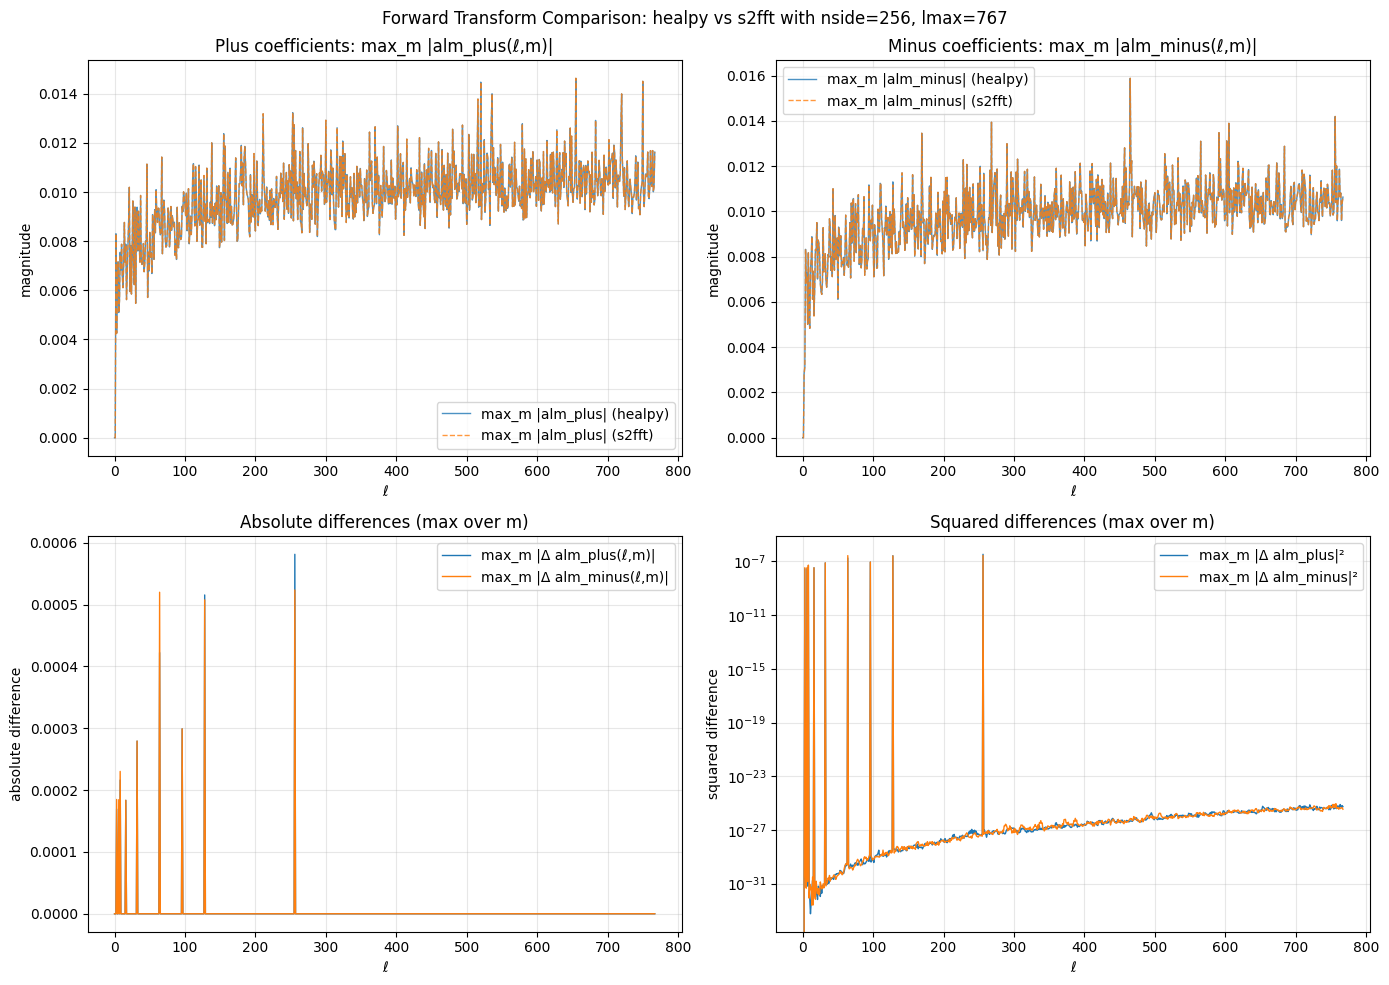

In [17]:
# Visualize forward transform results
alm_plus_hp_np = np.asarray(alm_plus_hp)
alm_minus_hp_np = np.asarray(alm_minus_hp)
alm_plus_s2_np = np.asarray(alm_plus_s2)
alm_minus_s2_np = np.asarray(alm_minus_s2)

L = lmax + 1
ells = np.arange(L)
ell_idx, m_idx = hp.Alm.getlm(lmax)

# Compute magnitudes and differences
abs_plus_hp = np.abs(alm_plus_hp_np)
abs_plus_s2 = np.abs(alm_plus_s2_np)
abs_minus_hp = np.abs(alm_minus_hp_np)
abs_minus_s2 = np.abs(alm_minus_s2_np)
plus_diff_mag = np.abs(alm_plus_hp_np - alm_plus_s2_np)
minus_diff_mag = np.abs(alm_minus_hp_np - alm_minus_s2_np)
plus_diff_sq = plus_diff_mag**2
minus_diff_sq = minus_diff_mag**2

# Compute max per ell
plus_hp_ell = np.zeros(L)
plus_s2_ell = np.zeros(L)
minus_hp_ell = np.zeros(L)
minus_s2_ell = np.zeros(L)
plus_diff_ell = np.zeros(L)
minus_diff_ell = np.zeros(L)
plus_diff_sq_ell = np.zeros(L)
minus_diff_sq_ell = np.zeros(L)

for ell in range(L):
    mask = ell_idx == ell
    if not np.any(mask):
        continue
    plus_hp_ell[ell] = abs_plus_hp[mask].max()
    plus_s2_ell[ell] = abs_plus_s2[mask].max()
    minus_hp_ell[ell] = abs_minus_hp[mask].max()
    minus_s2_ell[ell] = abs_minus_s2[mask].max()
    plus_diff_ell[ell] = plus_diff_mag[mask].max()
    minus_diff_ell[ell] = minus_diff_mag[mask].max()
    plus_diff_sq_ell[ell] = plus_diff_sq[mask].max()
    minus_diff_sq_ell[ell] = minus_diff_sq[mask].max()

# Create 2x2 plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(ells, plus_hp_ell, label='max_m |alm_plus| (healpy)', lw=1, alpha=0.8)
ax.plot(ells, plus_s2_ell, '--', label='max_m |alm_plus| (s2fft)', lw=1, alpha=0.8)
ax.set_title('Plus coefficients: max_m |alm_plus(ℓ,m)|')
ax.set_xlabel('ℓ')
ax.set_ylabel('magnitude')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(ells, minus_hp_ell, label='max_m |alm_minus| (healpy)', lw=1, alpha=0.8)
ax.plot(ells, minus_s2_ell, '--', label='max_m |alm_minus| (s2fft)', lw=1, alpha=0.8)
ax.set_title('Minus coefficients: max_m |alm_minus(ℓ,m)|')
ax.set_xlabel('ℓ')
ax.set_ylabel('magnitude')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(ells, plus_diff_ell, label='max_m |Δ alm_plus(ℓ,m)|', lw=1)
ax.plot(ells, minus_diff_ell, label='max_m |Δ alm_minus(ℓ,m)|', lw=1)
ax.set_title('Absolute differences (max over m)')
ax.set_xlabel('ℓ')
ax.set_ylabel('absolute difference')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(ells, plus_diff_sq_ell, label='max_m |Δ alm_plus|²', lw=1)
ax.plot(ells, minus_diff_sq_ell, label='max_m |Δ alm_minus|²', lw=1)
ax.set_title('Squared differences (max over m)')
ax.set_xlabel('ℓ')
ax.set_ylabel('squared difference')
ax.set_yscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'Forward Transform Comparison: healpy vs s2fft with nside={nside}, lmax={lmax}')

plt.tight_layout()
plt.show()

## Inverse Transform: alm2map_spin

Convert E/B mode spherical harmonic coefficients back to Q/U Stokes parameter maps.

In [8]:
# Use the healpy alms as input
# Transform with healpy
q_hp_rec, u_hp_rec = hp.alm2map_spin(
    [np.array(alm_plus_hp), np.array(alm_minus_hp)],
    nside=nside,
    spin=spin,
    lmax=lmax,
)

# Transform with s2fft
q_s2_rec, u_s2_rec = alm2map_spin_s2fft(
    alm_plus_hp,
    alm_minus_hp,
    nside=nside,
    spin=spin,
    lmax=lmax,
    healpy_ordering=True,
    method='jax',
)

# Convert to numpy arrays
q_hp_arr = np.asarray(q_hp_rec)
u_hp_arr = np.asarray(u_hp_rec)
q_s2_arr = np.asarray(q_s2_rec)
u_s2_arr = np.asarray(u_s2_rec)

# Compute errors
print('Backward (alm2map_spin):')
print('  max |ΔQ| =', np.max(np.abs(q_hp_arr - q_s2_arr)))
print('  max |ΔU| =', np.max(np.abs(u_hp_arr - u_s2_arr)))
print('  rel |ΔQ| =', rel_err(q_hp_arr, q_s2_arr))
print('  rel |ΔU| =', rel_err(u_hp_arr, u_s2_arr))

Backward (alm2map_spin):
  max |ΔQ| = 0.05273774757750116
  max |ΔU| = 0.058732865900925746
  rel |ΔQ| = 0.012702431267948922
  rel |ΔU| = 0.013464275658061768


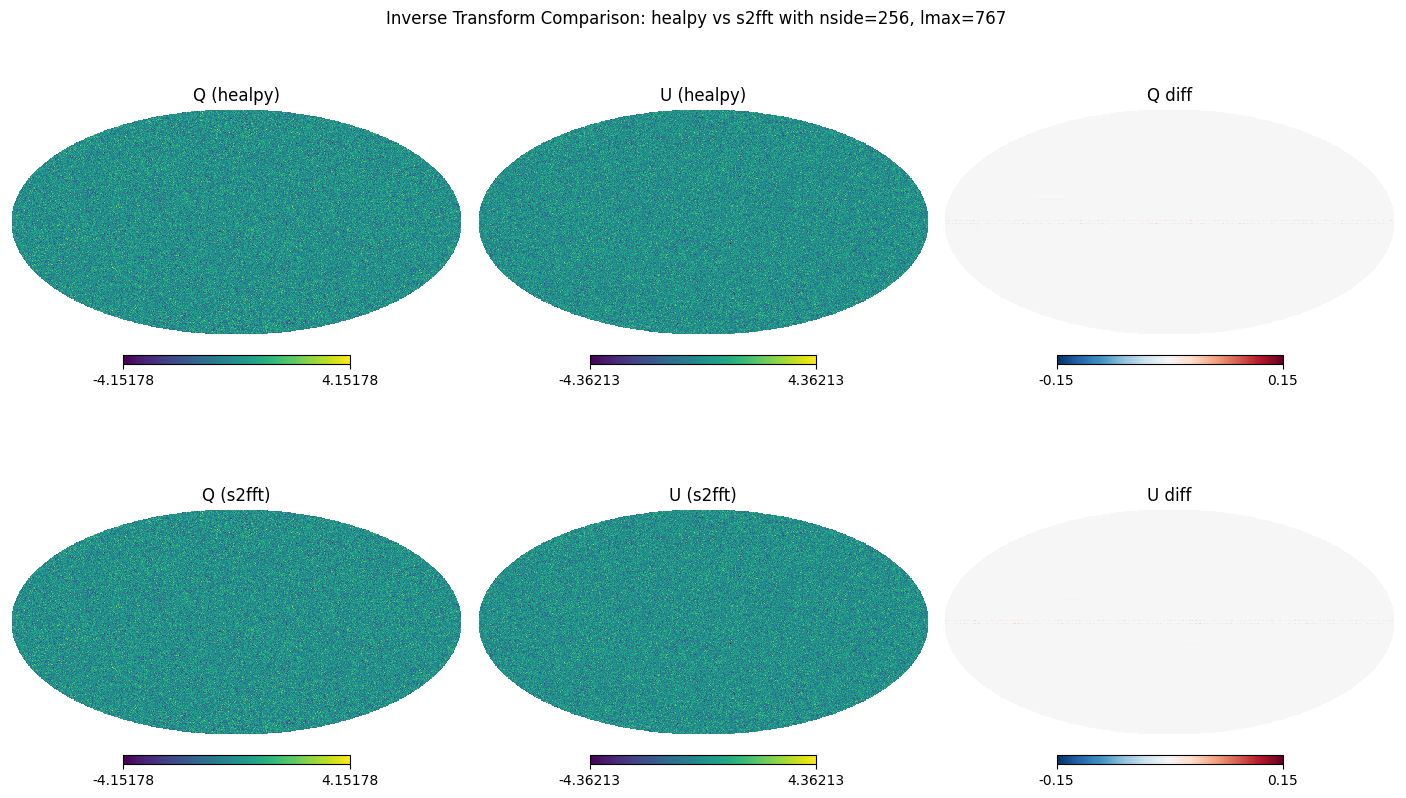

In [19]:
# Visualize inverse transform results
plt.figure(figsize=(14, 8))
plt.suptitle(f'Inverse Transform Comparison: healpy vs s2fft with nside={nside}, lmax={lmax}')

q_diff = q_hp_arr - q_s2_arr
u_diff = u_hp_arr - u_s2_arr

q_span = np.max(np.abs(np.concatenate([q_hp_arr, q_s2_arr])))
u_span = np.max(np.abs(np.concatenate([u_hp_arr, u_s2_arr])))

hp.mollview(q_hp_arr, title='Q (healpy)', sub=(2, 3, 1), cbar=True, min=-q_span, max=q_span)
hp.mollview(u_hp_arr, title='U (healpy)', sub=(2, 3, 2), cbar=True, min=-u_span, max=u_span)
hp.mollview(q_diff, title='Q diff', sub=(2, 3, 3), cbar=True, min=-0.15, max=0.15, cmap='RdBu_r')

hp.mollview(q_s2_arr, title='Q (s2fft)', sub=(2, 3, 4), cbar=True, min=-q_span, max=q_span)
hp.mollview(u_s2_arr, title='U (s2fft)', sub=(2, 3, 5), cbar=True, min=-u_span, max=u_span)
hp.mollview(u_diff, title='U diff', sub=(2, 3, 6), cbar=True, min=-0.15, max=0.15, cmap='RdBu_r')
plt.show()

In [13]:
import numpy.testing as npt

MSE_minus = np.mean((minus_hp_ell - minus_s2_ell) ** 2)
MSE_plus = np.mean((plus_hp_ell - plus_s2_ell) ** 2)
MSE_q_map = np.mean((q_hp_arr - q_s2_arr) ** 2)
MSE_u_map = np.mean((u_hp_arr - u_s2_arr) ** 2)

print('  MSE minus_ell =', MSE_minus)
print('  MSE plus_ell =', MSE_plus)
print('  MSE q_map =', MSE_q_map)
print('  MSE u_map =', MSE_u_map)

npt.assert_allclose(minus_hp_ell, minus_s2_ell, atol=1e-2, rtol=1e-5)  # acceptable
npt.assert_allclose(plus_hp_ell, plus_s2_ell, atol=1e-2, rtol=1e-5)  # acceptable
npt.assert_allclose(u_hp_arr, u_s2_arr, atol=0.2, rtol=1e-5)  # this is not good
npt.assert_allclose(q_hp_arr, q_s2_arr, atol=0.2, rtol=1e-5)  # this is not good

  MSE minus_ell = 1.1680440612586204e-10
  MSE plus_ell = 6.61646952631111e-11
  MSE q_map = 1.5867452782526033e-06
  MSE u_map = 1.5807106177240472e-06
